In [22]:
import os
os.chdir(r"C:\Users\haley\OneDrive\Desktop\School\Summer '25\MIS 761")

In [23]:
#Evaluate the data

In [24]:
import pandas as pd
df = pd.read_csv("risk_behavior_features.csv")
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   73 non-null     int64  
 1   Gender                73 non-null     object 
 2   Education Level       73 non-null     object 
 3   Marital Status        73 non-null     object 
 4   Number of Dependents  73 non-null     int64  
 5   Income                73 non-null     int64  
 6   Credit Score          73 non-null     int64  
 7   Debt-to-Income Ratio  73 non-null     float64
 8   Assets Value          73 non-null     int64  
 9   Defaults Records      73 non-null     int64  
 10  Employment Status     73 non-null     object 
 11  Years in Current Job  73 non-null     int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 7.0+ KB


,Age,Gender,Education Level,Marital Status,Number of Dependents,Income,Credit Score,Debt-to-Income Ratio,Assets Value,Defaults Records,Employment Status,Years in Current Job
0,36,Female,Bachelor's,Divorced,2,56789,715,0.25,158765,2,Employed,6
1,37,Non-binary,Master's,Single,3,91234,789,0.18,176543,0,Employed,10
2,45,Male,Bachelor's,Divorced,1,65432,723,0.25,134567,1,Employed,6
3,39,Male,Master's,Single,0,92345,801,0.15,192345,0,Employed,10
4,40,Female,Master's,Married,1,76543,756,0.22,162345,0,Employed,8


In [25]:
#check for missing values
df.isnull().sum()

Age                     0
Gender                  0
Education Level         0
Marital Status          0
Number of Dependents    0
Income                  0
Credit Score            0
Debt-to-Income Ratio    0
Assets Value            0
Defaults Records        0
Employment Status       0
Years in Current Job    0
dtype: int64

In [26]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Convert categorical variables to dummy variables
df_dummies = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

print(df_dummies.head())
#check column names
print(df_dummies.columns.tolist())

   Age  Number of Dependents  Income  Credit Score  Debt-to-Income Ratio  \
0   36                     2   56789           715                  0.25   
1   37                     3   91234           789                  0.18   
2   45                     1   65432           723                  0.25   
3   39                     0   92345           801                  0.15   
4   40                     1   76543           756                  0.22   

   Assets Value  Defaults Records  Years in Current Job  Gender_Male  \
0        158765                 2                     6        False   
1        176543                 0                    10        False   
2        134567                 1                     6         True   
3        192345                 0                    10         True   
4        162345                 0                     8        False   

   Gender_Non-binary  Education Level_Doctorate  Education Level_High School  \
0              False          

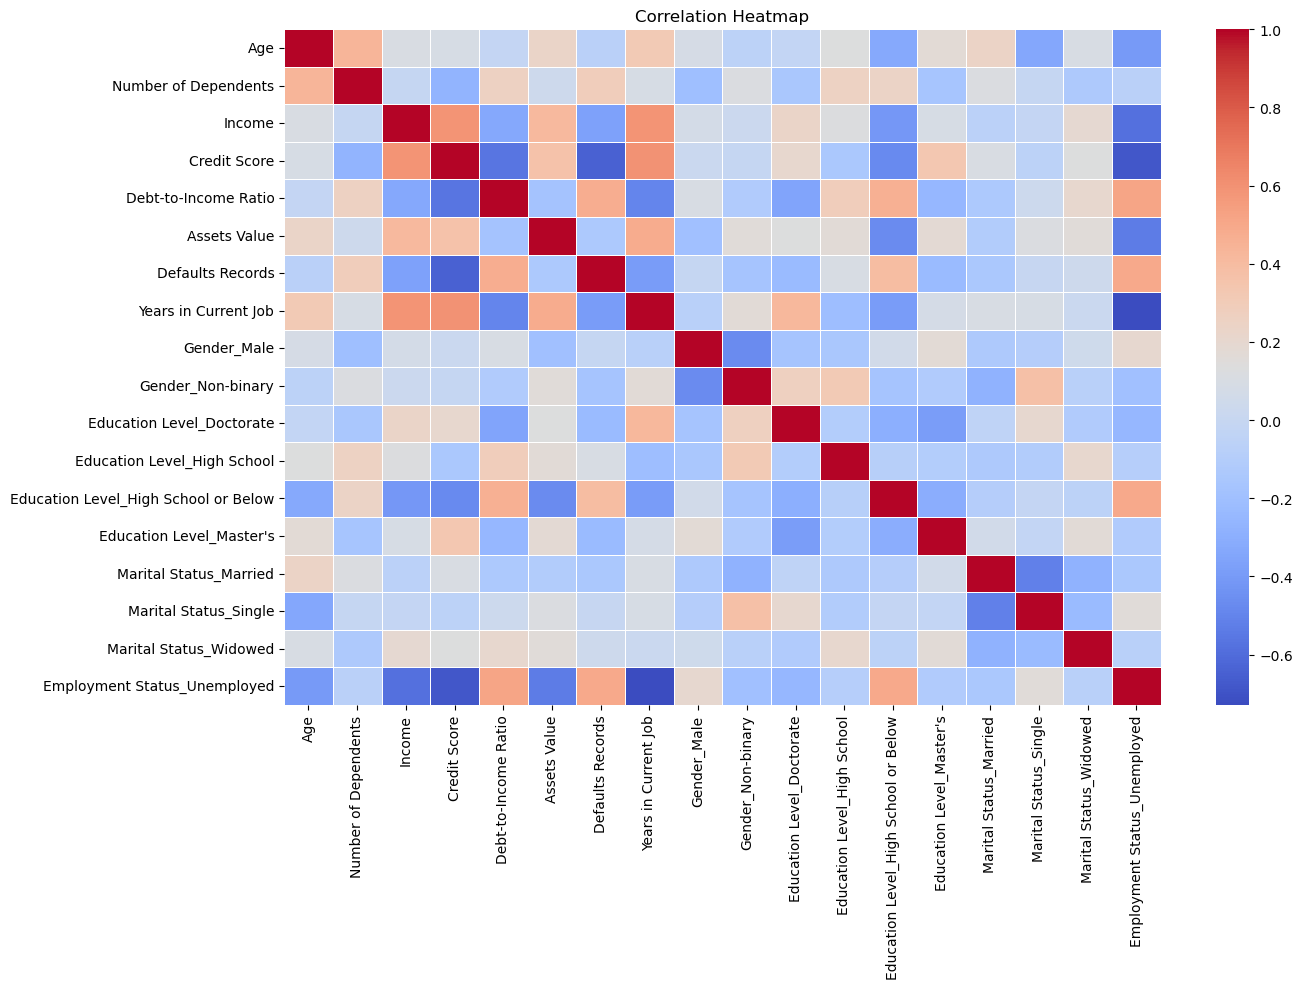

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Correlation heat map
correlation_matrix = df_dummies.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Strong correlations are seen between Assets Value and Income. Closest to 1.

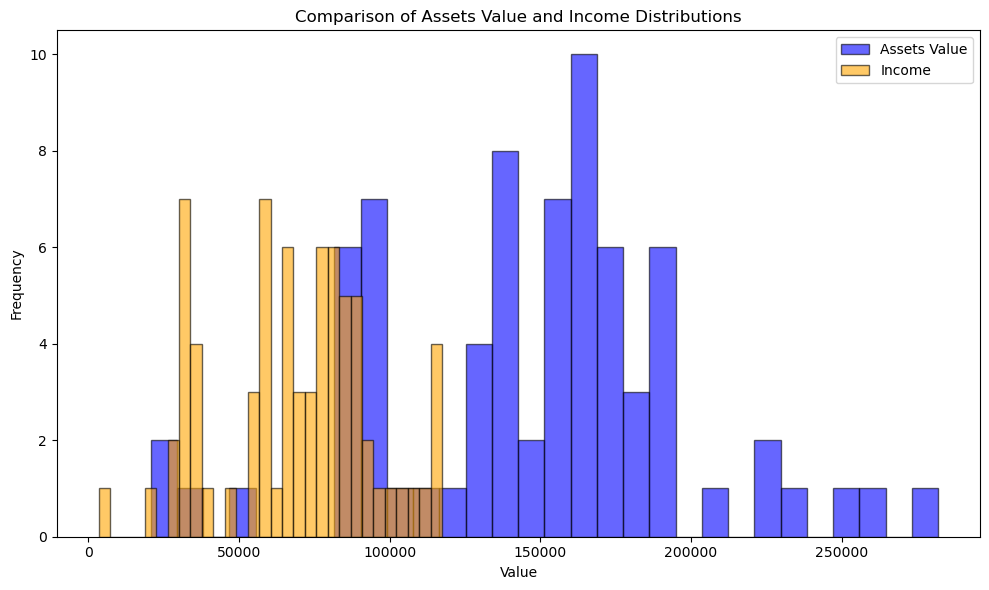

In [28]:
#histogram
plt.figure(figsize=(10, 6))

plt.hist(df_dummies['Assets Value'], bins=30, alpha=0.6, label='Assets Value',
         color='blue', edgecolor='black')

plt.hist(df_dummies['Income'], bins=30, alpha=0.6, label='Income',
         color='orange', edgecolor='black')

plt.title('Comparison of Assets Value and Income Distributions')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
#View the statistics
print(df_dummies[['Income', 'Assets Value']].describe())

              Income   Assets Value
count      73.000000      73.000000
mean    68188.643836  146890.287671
std     25709.974343   50949.713240
min      3512.000000   20626.000000
25%     54754.000000  114375.000000
50%     70978.000000  156630.000000
75%     85000.000000  172345.000000
max    117392.000000  282006.000000


The income shows to be more concentrated at lower values, which suggests that theres a skewed distribution with a cluster in the lower ranges. Assets Value seems more spread out, with higher values accross the range. 

In [30]:
from scipy.stats import ttest_ind

median_income = df_dummies['Income'].median()
high_income_group = df_dummies[df_dummies['Income'] > median_income]['Assets Value']
low_income_group = df_dummies[df_dummies['Income'] <= median_income]['Assets Value']

t_stat, p_val = ttest_ind(high_income_group, low_income_group, equal_var=False)

print("Independent T-Test")
print("Null Hypothesis: No difference in mean asset value between income groups")
print("Alternative Hypothesis: High-income group has a different mean asset value")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

Independent T-Test
Null Hypothesis: No difference in mean asset value between income groups
Alternative Hypothesis: High-income group has a different mean asset value
T-Statistic: 2.8942
P-Value: 0.0050


We conducted an independent t-test to evaluate whether there was a difference in Asset Values, between people with high and low incomes (based on the median income). The null hupothesis is that there is no difference in mean asset value between income groups. The alternative hypothesis is that high-income people have different mean asset value than low-income people. With a P-value of 0.0050, we reject the null hypothesis. This suggests that there's a significant difference in asset values between income groups. 

In [33]:
from scipy.stats import f_oneway, chi2_contingency

df_dummies['Income Group'] = pd.qcut(df_dummies['Income'], q=4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

grouped_assets = [
    df_dummies[df_dummies['Income Group'] == group]['Assets Value']
    for group in df_dummies['Income Group'].unique()
]

anova_stat, anova_p = f_oneway(*grouped_assets)

print("One-Way ANOVA")
print("H₀: Mean asset value is the same across income groups")
print(f"F-Statistic: {anova_stat:.4f}, P-Value: {anova_p:.4e}\n")

One-Way ANOVA
H₀: Mean asset value is the same across income groups
F-Statistic: 4.8333, P-Value: 4.1178e-03

